In [25]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

load_dotenv()
llm = ChatGroq(model=os.getenv("GROQ_MODEL"),
        api_key=os.getenv("GROQ_API_KEY"))

In [26]:
class AgentState(TypedDict):
    product: str
    reviews: str
    sentiment: str
    recommendation: str

In [27]:
def research_product(state: AgentState) -> AgentState:
    print('research_product - entry state type:', type(state))
    product = state['product']
    prompt = f"collect and summarize reviews for {product}. Include both positive and negative reviews."
    state['reviews'] = llm.invoke(prompt)
    print('research_product - reviews type:', type(state['reviews']))
    print('research_product - exit state type:', type(state))
    return state

In [28]:
def sentiment_analysis(state: AgentState) -> AgentState:
    print('sentiment_analysis - entry state type:', type(state))
    reviews = state.get('reviews', '')
    prompt = f"analyze the sentiment of these reviews: {reviews}. \nIs the overall sentiment positive, negative, or mixed?"
    state['sentiment'] = llm.invoke(prompt)
    print('sentiment_analysis - sentiment type:', type(state['sentiment']))
    print('sentiment_analysis - exit state type:', type(state))
    return state

In [29]:
def recommendation(state: AgentState) -> AgentState:
    print('recommendation - entry state type:', type(state))
    sentiment = state.get('sentiment', '')
    product = state.get('product', '')
    prompt = f"based on the sentiment {sentiment} \n would you recommend buying this {product}? Why or why not?"
    state['recommendation'] = llm.invoke(prompt)
    print('recommendation - recommendation type:', type(state['recommendation']))
    print('recommendation - exit state type:', type(state))
    return state

In [30]:
graph = StateGraph(AgentState)
graph.add_node("research_product", research_product)
graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("recommendation", recommendation)
graph.add_edge(START, "research_product")
graph.add_edge("research_product", "sentiment_analysis")
graph.add_edge("sentiment_analysis", "recommendation")
graph.add_edge("recommendation", END)
workflow = graph.compile()
initial_state = {"product": "iPhone 15"}

output = workflow.invoke(initial_state)
print(output)

research_product - entry state type: <class 'dict'>
research_product - reviews type: <class 'langchain_core.messages.ai.AIMessage'>
research_product - exit state type: <class 'dict'>
sentiment_analysis - entry state type: <class 'dict'>
sentiment_analysis - sentiment type: <class 'langchain_core.messages.ai.AIMessage'>
sentiment_analysis - exit state type: <class 'dict'>
recommendation - entry state type: <class 'dict'>
recommendation - recommendation type: <class 'langchain_core.messages.ai.AIMessage'>
recommendation - exit state type: <class 'dict'>
{'product': 'iPhone 15', 'reviews': AIMessage(content="**Please note: Since the iPhone 15 has not been officially released by Apple, the following review summary is based on rumored specifications and features, as well as early reviews from tech enthusiasts and experts who have had access to the device.**\n\n**Positive Reviews:**\n\n1. **Improved Cameras:** Many reviewers have praised the iPhone 15's camera system, which is rumored to fea

In [31]:
output.keys()

dict_keys(['product', 'reviews', 'sentiment', 'recommendation'])

In [34]:
output["recommendation"]

AIMessage(content="Based on the sentiment analysis, I would recommend buying the iPhone 15, but with some reservations. The positive reviews highlight the device's improved cameras, faster performance, new design, and longer battery life, which are significant upgrades. However, the negative reviews mention the high price tag, lack of major upgrades, and software issues, which might be a concern for some buyers.\n\nIf you're due for an upgrade and want a device with the latest features and improvements, the iPhone 15 might be a good choice. However, if you're looking for a game-changing device with significant innovations, you might want to consider other options or wait for future releases.\n\nAdditionally, if you're on a budget or don't want to spend a lot on a new device, you might want to consider other options or wait for the price to drop. Ultimately, the decision to buy the iPhone 15 depends on your individual needs and priorities.\n\nIt's also worth noting that the neutral revi

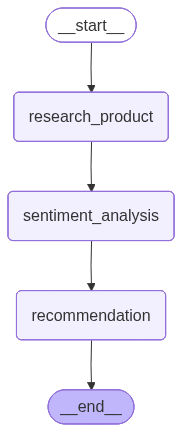

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [40]:
output['sentiment'].content

"The overall sentiment of the reviews is generally positive, but with some mixed and negative comments. The positive reviews highlight the iPhone 15's improved cameras, faster performance, new design, and longer battery life. However, some reviewers have expressed disappointment with the lack of major upgrades, no headphone jack, high price tag, and software issues.\n\nThe negative reviews are mostly related to the device's high price and lack of significant innovations compared to its predecessor. The neutral reviews note that the iPhone 15 is similar to the iPhone 14 and not a game-changing device, but still offers a solid user experience.\n\nOverall, the positive comments outweigh the negative ones, but the mixed and negative reviews prevent the overall sentiment from being overwhelmingly positive. Therefore, the sentiment can be characterized as mostly positive with some reservations."